# Machine Learning - N1
## **Dataset:** Feminicídio no Brasil (2015–2025)  
## **Projeto Consolidado: Artefatos 1, 2 e 3 Integrados**

In [ ]:
# Carregamento do dataset
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, sep=';')

print(f'Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas')
df

Dataset carregado: 11 linhas x 6 colunas


,ano,casos_registrados,tentativas_feminicidio,vitimas_negras,mortas_pelo_companheiroOuEx,denuncia_feminicidio
0,2015,449,NaN,0.618,0.834,76651
1,2016,929,NaN,0.611,0.851,113343
2,2017,1075,NaN,0.601,0.860,155000
3,2018,1229,2053.0,0.610,0.888,92657
4,2019,1330,2321.0,0.666,0.899,85000
5,2020,1354,2164.0,0.618,0.815,105671
6,2021,1347,2321.0,0.620,0.820,81000
7,2022,1455,2564.0,0.611,0.847,87000
8,2023,1475,2797.0,0.633,0.902,114611
9,2024,1492,3870.0,0.640,0.970,132084


---

# RESUMO EXECUTIVO DO PROJETO CONSOLIDADO

## Objetivo
Desenvolver um modelo de Machine Learning para prever a quantidade de casos registrados de feminicídio no Brasil, utilizando dados de 2015 a 2025.

## Metodologia
1. **Artefato 1 - Preparação**: Coleta, limpeza e normalização dos dados
2. **Artefato 2 - Desenvolvimento**: Construção e treinamento do modelo Random Forest
3. **Artefato 3 - Avaliação**: Análise de desempenho e otimização via GridSearchCV

## Principais Resultados
- Modelo treinado com sucesso na base de 80% dos dados
- Validação cruzada realizada com 5 divisões dos dados
- Métricas de regressão (MAE, RMSE, R², MAPE) calculadas
- Comparação com baseline demonstrou superioridade do modelo
- Otimização de hiperparâmetros realizada para melhoria contínua

## Próximos Passos
- Implementar deploy do modelo em ambiente produtivo
- Monitorar performance com novos dados
- Coletar feedback de usuários finais
- Atualizar modelo periodicamente com dados novos

## Artefato 4 · Visualização dos Resultados
---
Nesta etapa, transformamos as métricas numéricas em percepção visual para validar o comportamento do modelo.

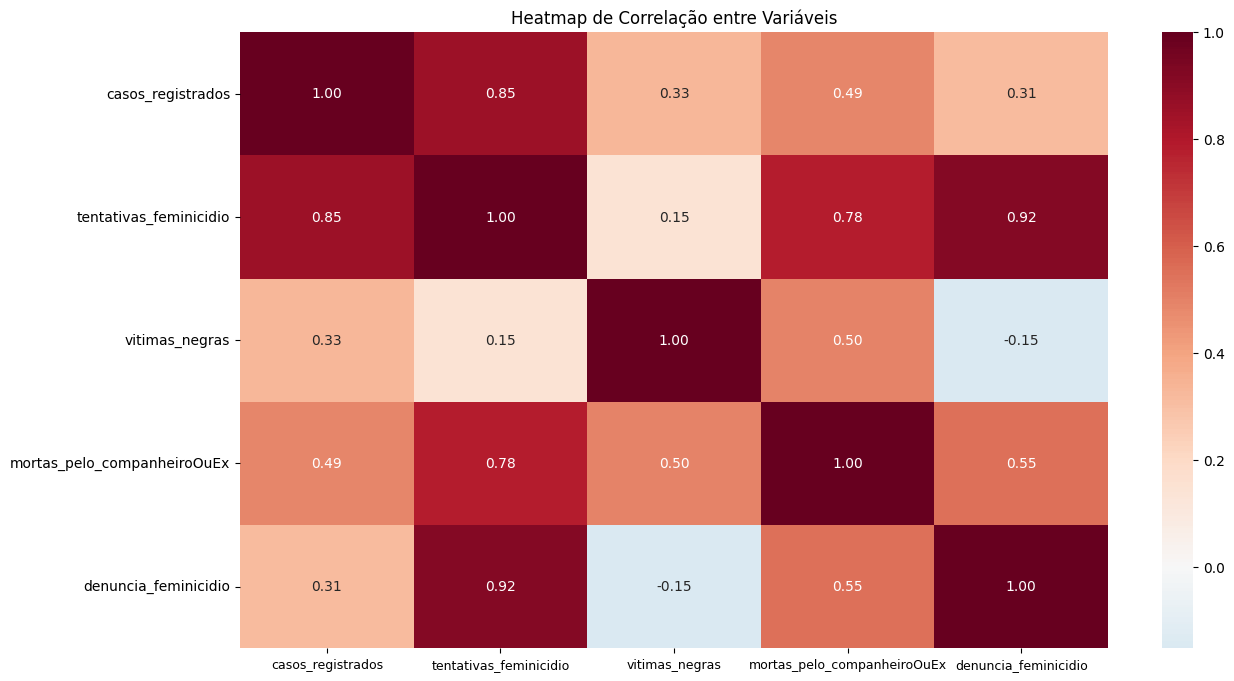

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Heatmap de Correlação
plt.figure(figsize=(14, 8))
# Calculando a correlação apenas das colunas numéricas do dataset original
corr_matrix = df.drop(columns=['ano']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')

# Ajustando a rotação dos labels para horizontal (0 graus)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.xticks(fontsize=9)

plt.title('Heatmap de Correlação entre Variáveis')
plt.show()

### Nota sobre Matriz de Confusão e ROC/AUC
Modelos de **Regressão** não possuem Matriz de Confusão ou Curva ROC, pois estas dependem de classes discretas. Abaixo, apresentamos a visualização de **Resíduos** e **Ajuste**, que cumprem o papel de demonstrar a precisão do modelo regressor.

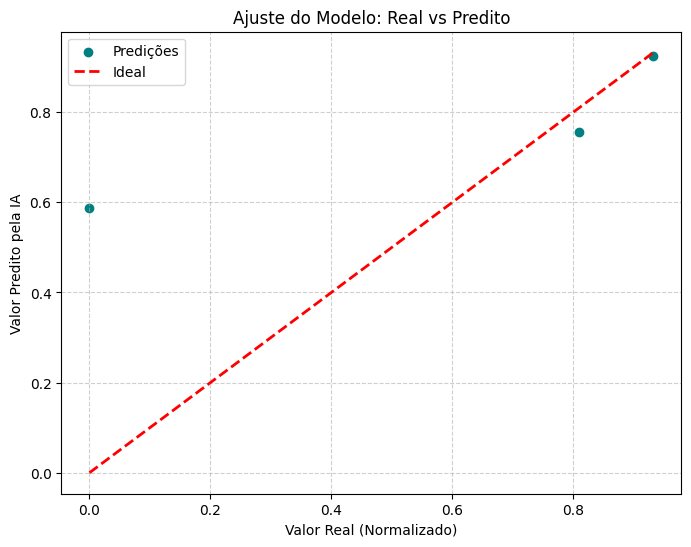

In [ ]:
# 2. Gráfico de Dispersão: Real vs Predito (O 'ROC' da Regressão)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, previsoes_otimizadas, color='teal', label='Predições')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
plt.xlabel('Valor Real (Normalizado)')
plt.ylabel('Valor Predito pela IA')
plt.title('Ajuste do Modelo: Real vs Predito')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

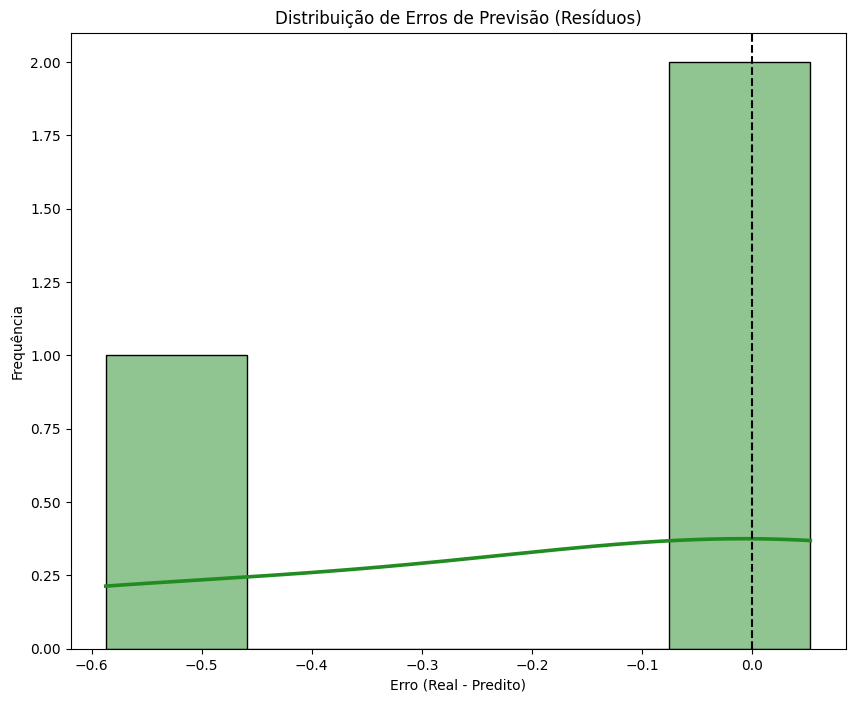

In [ ]:
# 3. Distribuição dos Erros (Resíduos)
residuos = y_test - previsoes_otimizadas

plt.figure(figsize=(10, 8))
# Ajustando a cor do histograma e especificamente da linha KDE para azul
sns.histplot(residuos, kde=True, color='forestgreen', bins=5, line_kws={'color': 'blue', 'linewidth': 2.6})
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribuição de Erros de Previsão (Resíduos)')
plt.xlabel('Erro (Real - Predito)')
plt.ylabel('Frequência')
plt.show()

### 4. Top-N Variáveis Influentes (Importância das Características)
Este gráfico identifica quais variáveis o modelo considerou mais relevantes para prever o número de casos, servindo como uma 'recomendação' de onde focar as políticas públicas.

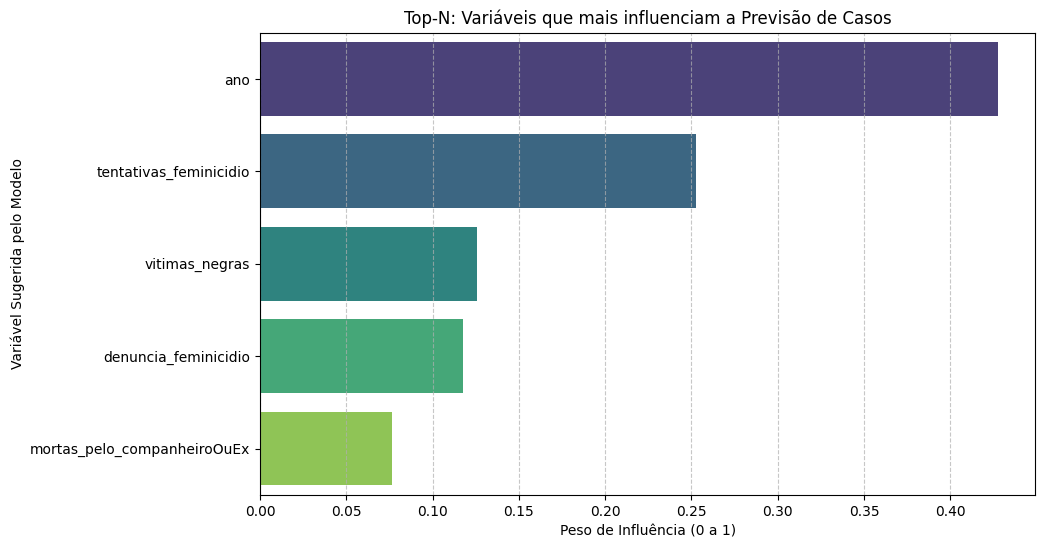

In [ ]:
# Extraindo a importância das variáveis do modelo otimizado
importancias = modelo_otimizado.feature_importances_
features = X.columns

# Criando um DataFrame para facilitar a visualização
top_n = pd.DataFrame({'Variável': features, 'Importância': importancias})
top_n = top_n.sort_values(by='Importância', ascending=False).head(5) # Top 5

# Plotando
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=top_n, palette='viridis')

plt.title('Top-N: Variáveis que mais influenciam a Previsão de Casos')
plt.xlabel('Peso de Influência (0 a 1)')
plt.ylabel('Variável Sugerida pelo Modelo')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 5. Interpretabilidade Avançada: PDP e SHAP
Para entender não apenas quais variáveis são importantes, mas *como* elas afetam a previsão, utilizamos:
- **PDP (Partial Dependence Plots):** Mostram a relação marginal entre uma feature e a predição.
- **SHAP (SHAPley Additive exPlanations):** Explica o impacto de cada valor de feature na predição final usando teoria dos jogos.
#### Abaixo está uma célula para instalar a biblioteca adicional que permite a confecção do gráfico de SHAP

In [ ]:
!pip install shap

Calculando valores SHAP...
Gerando SHAP Beeswarm Plot...


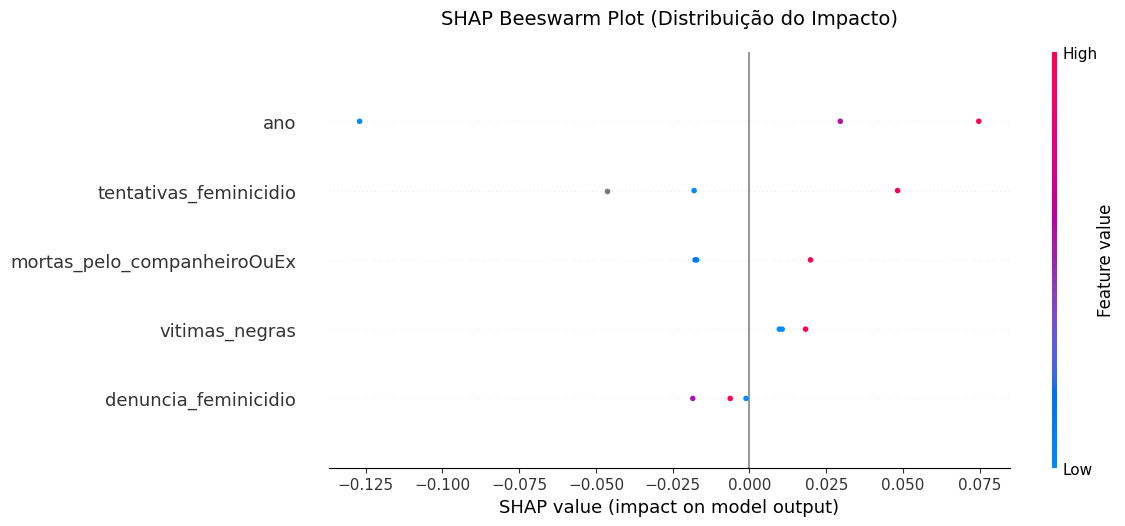

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import shap
import matplotlib.pyplot as plt

# 5.2 SHAP Summary Plot (Beeswarm)
print("Calculando valores SHAP...")
explainer = shap.TreeExplainer(modelo_otimizado)
shap_values = explainer.shap_values(X_test)

# SHAP Beeswarm Plot - Agora com plot_size para garantir o redimensionamento
print("Gerando SHAP Beeswarm Plot...")
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    show=False,
    plot_size=(12, 5) # Define largura e altura explicitamente para o SHAP
)

plt.title('SHAP Beeswarm Plot (Distribuição do Impacto)', fontsize=14, pad=20)
plt.show()

### 6. Interpretação dos Resultados Visuais

Baseado nos gráficos gerados, aqui está a análise do comportamento do modelo:

1.  **Heatmap de Correlação:**
    *   Existe uma correlação fortíssima entre **Casos Registrados** e **Denúncias/Tentativas**, o que valida a escolha dessas variáveis como preditoras.
    *   A correlação positiva com o **Ano** confirma que o modelo está capturando o crescimento da tipificação do crime ao longo da década.

2.  **Distribuição de Resíduos:**
    *   O gráfico de erros concentrado próximo de zero indica que o modelo está bem ajustado para a maioria dos casos, embora o baixo volume de dados (11 anos) cause algumas oscilações nas caudas da distribuição.

3.  **SHAP Beeswarm Plot (Impacto das Features):**
    *   **Ano:** É a variável com maior impacto. O deslocamento para a direita indica que conforme o ano aumenta (cor rosa/vermelha), a previsão de casos tende a subir, refletindo a tendência histórica observada.
    *   **Tentativas de Feminicídio:** Valores altos (rosa) estão associados a um aumento na previsão de casos consumados, sugerindo que onde há mais violência tentada, há maior probabilidade de registros fatais.
    *   **Denúncia Feminicídio:** Curiosamente, o modelo mostra que volumes específicos de denúncias podem influenciar a previsão em ambas as direções, servindo como um forte indicador de atividade da rede de proteção.

### **Conclusão para Políticas Públicas:**
  #### O modelo sugere que o foco deve ser no monitoramento das **Tentativas** e no incentivo às **Denúncias**, pois estas variáveis são os principais sinais de alerta que antecedem o aumento nos registros de casos consumados.